Average times:
Fetch: 0.4931
Save: 0.4291
Parse: 0.0983
Link score: 2.0931
Link score per link: 0.020448


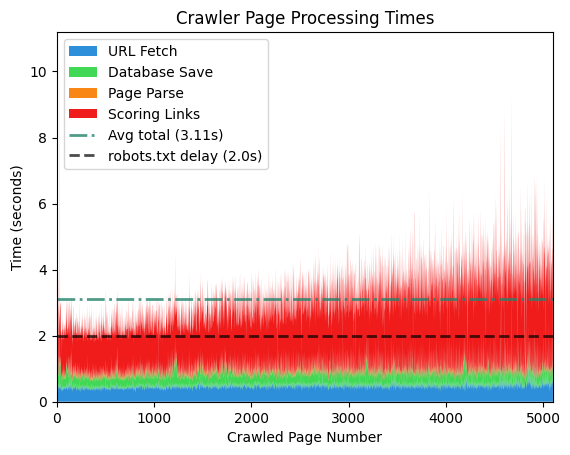

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("crawler_time_log.csv")

# ---- Averages ----
avg_times = df.mean()

avg_fetch = avg_times["fetch_time"]
avg_save = avg_times["page_save_time"]
avg_parse = avg_times["page_parse_time"]
avg_score = avg_times["links_score_time"]

# Average link score time per link
df["score_per_link"] = df["links_score_time"] / df["link_count"]
avg_score_per_link = df["score_per_link"].mean()

print("Average times:")
print(f"Fetch: {avg_fetch:.4f}")
print(f"Save: {avg_save:.4f}")
print(f"Parse: {avg_parse:.4f}")
print(f"Link score: {avg_score:.4f}")
print(f"Link score per link: {avg_score_per_link:.6f}")

# ---- Stacked (layer) plot ----
x = range(len(df))

plt.figure()

# Softer color palette (muted)
colors = ["#2d8fda84", "#41d85578", "#f8871578", "#f01c1c84"]

# Stackplot with transparency
plt.stackplot(
    x,
    df["fetch_time"],
    df["page_save_time"],
    df["page_parse_time"],
    df["links_score_time"],
    labels=[
        "URL Fetch",
        "Database Save",
        "Page Parse",
        "Scoring Links"
    ],
    colors=colors,
    alpha=1.0,
    linewidth=0
)

# ---- Average TOTAL processing time ----
df["total_time"] = (
    df["fetch_time"]
    + df["page_save_time"]
    + df["page_parse_time"]
    + df["links_score_time"]
)

avg_total_time = df["total_time"].mean()

plt.axhline(
    avg_total_time,
    color="#23836b",
    linestyle='-.',
    linewidth=2,
    label=f"Avg total ({avg_total_time:.2f}s)",
    alpha= 0.8
)

# ---- Robots.txt delay line ----
plt.axhline(
    2.0,
    color='black',
    linestyle='--',
    linewidth=2,
    label="robots.txt delay (2.0s)",
    alpha=0.7
)

# ---- Remove empty space ----
plt.xlim(0, len(df) - 1)
plt.margins(x=0)

# Labels
plt.legend(loc="upper left")
plt.xlabel("Crawled Page Number")
plt.ylabel("Time (seconds)")
plt.title("Crawler Page Processing Times")

plt.show()